# Macro autoresearch results analysis

Analyze `results.tsv` for maximum-CAGR-without-ruin experiments benchmarked against DBMF. The progress plot mirrors the original repo workflow and writes `progress.png`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

path = Path("results.tsv")
if path.exists():
    df = pd.read_csv(path, sep="	")
else:
    df = pd.DataFrame(
        columns=[
            "commit",
            "cagr",
            "ruined",
            "dbmf_cagr",
            "dbmf_ruined",
            "excess_cagr_vs_dbmf",
            "status",
            "description",
        ]
    )

for column in ["cagr", "dbmf_cagr", "excess_cagr_vs_dbmf"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["ruined"] = df["ruined"].astype(str).str.strip().str.lower()
df["dbmf_ruined"] = df["dbmf_ruined"].astype(str).str.strip().str.lower()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 51
Columns: ['commit', 'cagr', 'ruined', 'dbmf_cagr', 'dbmf_ruined', 'excess_cagr_vs_dbmf', 'status', 'description']


,commit,cagr,ruined,dbmf_cagr,dbmf_ruined,excess_cagr_vs_dbmf,status,description
0,441d10f,0.159203,false,0.093904,false,0.065299,keep,baseline strategy benchmarked against DBMF
1,working,0.096517,false,0.093904,false,0.002613,discard,iter 1 sector_top1_6m_momentum: sector-expande...
2,bfa3a30,0.176131,false,0.093904,false,0.082227,keep,iter 2 sector_top1_3m_momentum: shorter 3m sec...
3,bf26fdd,0.179894,false,0.093904,false,0.085990,keep,iter 3 sector_top1_4m_momentum: 4m sector mome...
4,working,0.151054,false,0.093904,false,0.057150,discard,iter 4 sector_top1_9m_momentum: 9m momentum ma...
5,working,0.166424,false,0.093904,false,0.072520,discard,iter 5 sector_top1_blended_momentum: 3/6/12m b...
6,0344cda,0.187245,false,0.093904,false,0.093341,keep,iter 6 sector_top2_blended_momentum: top-2 ble...
7,working,0.128836,false,0.093904,false,0.034932,discard,iter 7 sector_top2_6m_momentum: top-2 6m momen...
8,working,0.098986,false,0.093904,false,0.005082,discard,iter 8 concentrated_top1_6m_momentum: concentr...
9,4569faa,0.220907,false,0.093904,false,0.127003,keep,iter 9 concentrated_top1_3m_momentum: fast con...


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("keep", 0)
n_discard = counts.get("discard", 0)
n_crash = counts.get("crash", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
discard    42
keep        9

Keep rate: 9/51 = 17.6%


In [3]:
eligible = df[(df["status"] == "keep") & (df["ruined"] == "false")].copy()
if not eligible.empty:
    best = eligible.loc[eligible["cagr"].idxmax()]
    print(f"Best CAGR: {best['cagr']:.6f}")
    print(f"DBMF CAGR: {best['dbmf_cagr']:.6f}")
    print(f"Excess CAGR vs DBMF: {best['excess_cagr_vs_dbmf']:.6f}")
    print(f"Description: {best['description']}")
else:
    print("No eligible non-ruined kept experiments yet.")

Best CAGR: 0.343744
DBMF CAGR: 0.093904
Excess CAGR vs DBMF: 0.249840
Description: iter 38 thematic_top1_1m_momentum: adds semiconductors/communication/biotech to capture AI and growth leadership as macro risk-on expression; beats DBMF


## CAGR progress over time

Track how the best non-ruined kept CAGR evolves as experiments progress. The running maximum is the kept frontier. `DBMF` is shown as the matched-window benchmark diagnostic.

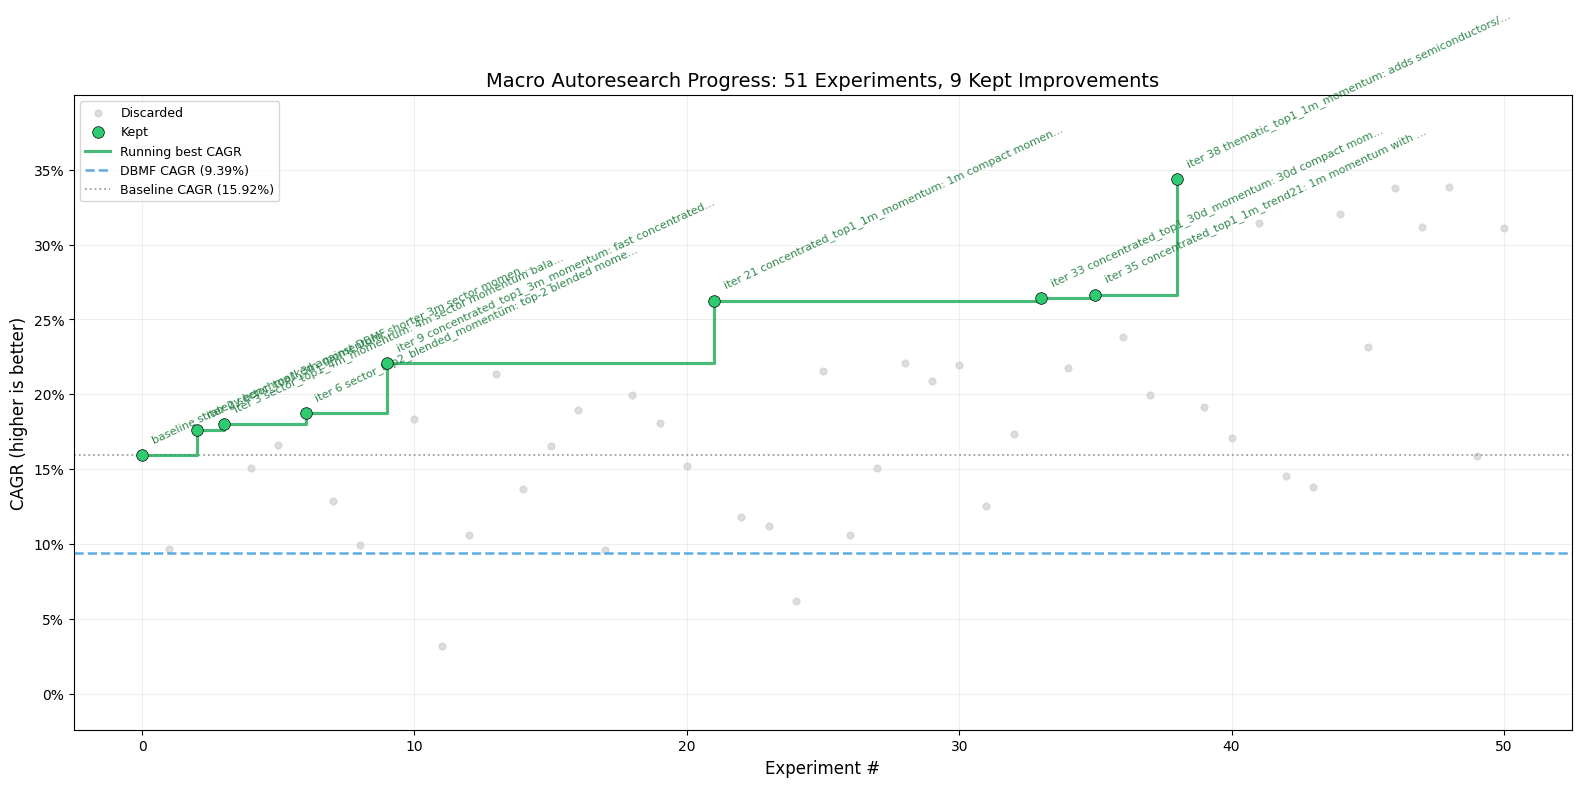

Saved to progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting while preserving original experiment numbers.
valid = df[df["status"] != "crash"].copy()
valid["experiment"] = valid.index
valid_nonruined = valid[valid["ruined"] == "false"].copy()

if valid_nonruined.empty:
    raise ValueError("No non-crashed, non-ruined experiments available to plot")

baseline_cagr = float(valid_nonruined.iloc[0]["cagr"])
dbmf_cagr = valid_nonruined["dbmf_cagr"].dropna()
dbmf_cagr = float(dbmf_cagr.iloc[0]) if not dbmf_cagr.empty else None

# Plot discarded non-ruined experiments as faint background dots.
disc = valid_nonruined[valid_nonruined["status"] == "discard"]
ax.scatter(
    disc["experiment"],
    disc["cagr"],
    c="#cccccc",
    s=24,
    alpha=0.65,
    zorder=2,
    label="Discarded",
)

# Plot ruined experiments separately if they exist.
ruined = valid[valid["ruined"] == "true"]
if not ruined.empty:
    ax.scatter(
        ruined["experiment"],
        ruined["cagr"],
        c="#e74c3c",
        s=28,
        alpha=0.75,
        marker="x",
        zorder=2,
        label="Ruined",
    )

# Plot kept experiments as prominent green dots.
kept_v = valid_nonruined[valid_nonruined["status"] == "keep"]
ax.scatter(
    kept_v["experiment"],
    kept_v["cagr"],
    c="#2ecc71",
    s=70,
    zorder=4,
    label="Kept",
    edgecolors="black",
    linewidths=0.5,
)

# Running maximum step line over kept experiments only.
running_best = kept_v["cagr"].cummax()
ax.step(
    kept_v["experiment"],
    running_best,
    where="post",
    color="#27ae60",
    linewidth=2.25,
    alpha=0.85,
    zorder=3,
    label="Running best CAGR",
)

# DBMF diagnostic benchmark line.
if dbmf_cagr is not None:
    ax.axhline(
        dbmf_cagr,
        color="#3498db",
        linewidth=1.8,
        linestyle="--",
        alpha=0.8,
        label=f"DBMF CAGR ({dbmf_cagr:.2%})",
    )

# Baseline strategy line.
ax.axhline(
    baseline_cagr,
    color="#7f8c8d",
    linewidth=1.3,
    linestyle=":",
    alpha=0.8,
    label=f"Baseline CAGR ({baseline_cagr:.2%})",
)

# Label each kept improvement.
for _, row in kept_v.iterrows():
    desc = str(row["description"]).strip()
    if len(desc) > 58:
        desc = desc[:55] + "..."
    ax.annotate(
        desc,
        (row["experiment"], row["cagr"]),
        textcoords="offset points",
        xytext=(6, 7),
        fontsize=8.0,
        color="#1a7a3a",
        alpha=0.9,
        rotation=25,
        ha="left",
        va="bottom",
    )

n_total = len(df)
n_kept = len(kept_v)
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("CAGR (higher is better)", fontsize=12)
ax.set_title(
    f"Macro Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements",
    fontsize=14,
)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Y-axis: include DBMF/baseline and all non-ruined results with a small margin.
y_values = valid_nonruined["cagr"].dropna().tolist()
if dbmf_cagr is not None:
    y_values.append(dbmf_cagr)
y_values.append(baseline_cagr)
y_min = min(y_values)
y_max = max(y_values)
margin = max((y_max - y_min) * 0.18, 0.01)
ax.set_ylim(y_min - margin, y_max + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary statistics

In [5]:
kept = df[(df["status"] == "keep") & (df["ruined"] == "false")].copy()
if kept.empty:
    print("No kept experiments yet.")
else:
    baseline_cagr = float(df.iloc[0]["cagr"])
    best_cagr = float(kept["cagr"].max())
    best_row = kept.loc[kept["cagr"].idxmax()]

    print(f"Baseline CAGR:    {baseline_cagr:.6f}")
    print(f"Best CAGR:        {best_cagr:.6f}")
    print(f"Total improvement:{best_cagr - baseline_cagr:+.6f} ({(best_cagr - baseline_cagr) / abs(baseline_cagr) * 100:.2f}%)")
    print(f"Best experiment:  {best_row['description']}")
    print()

    print("Cumulative effort per kept improvement:")
    for idx, row in kept.iterrows():
        desc = str(row["description"]).strip()
        print(f"  Experiment #{idx:3d}: cagr={row['cagr']:.6f} excess_vs_dbmf={row['excess_cagr_vs_dbmf']:+.6f}  {desc}")

Baseline CAGR:    0.159203
Best CAGR:        0.343744
Total improvement:+0.184541 (115.92%)
Best experiment:  iter 38 thematic_top1_1m_momentum: adds semiconductors/communication/biotech to capture AI and growth leadership as macro risk-on expression; beats DBMF

Cumulative effort per kept improvement:
  Experiment #  0: cagr=0.159203 excess_vs_dbmf=+0.065299  baseline strategy benchmarked against DBMF
  Experiment #  2: cagr=0.176131 excess_vs_dbmf=+0.082227  iter 2 sector_top1_3m_momentum: shorter 3m sector momentum may rotate faster into retail-accessible winners; beats DBMF
  Experiment #  3: cagr=0.179894 excess_vs_dbmf=+0.085990  iter 3 sector_top1_4m_momentum: 4m sector momentum balances quick rotation with less noise than 3m; beats DBMF
  Experiment #  6: cagr=0.187245 excess_vs_dbmf=+0.093341  iter 6 sector_top2_blended_momentum: top-2 blended momentum diversifies leadership while staying concentrated; beats DBMF
  Experiment #  9: cagr=0.220907 excess_vs_dbmf=+0.127003  iter 

## Top hits

In [6]:
kept = df[(df["status"] == "keep") & (df["ruined"] == "false")].copy()
kept["prev_cagr"] = kept["cagr"].shift(1)
kept["delta"] = kept["cagr"] - kept["prev_cagr"]

hits = kept.iloc[1:].copy().sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>9}  {'CAGR':>10}  Description")
print("-" * 96)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['cagr']:.6f}  {row['description']}")

if not hits.empty:
    print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank      Delta        CAGR  Description
------------------------------------------------------------------------------------------------
   1  +0.077094  0.343744  iter 38 thematic_top1_1m_momentum: adds semiconductors/communication/biotech to capture AI and growth leadership as macro risk-on expression; beats DBMF
   2  +0.041664  0.262571  iter 21 concentrated_top1_1m_momentum: 1m compact momentum tests faster rotation into sharp macro/sector bursts; beats DBMF
   3  +0.033662  0.220907  iter 9 concentrated_top1_3m_momentum: fast concentrated momentum may harvest sharp sector/commodity bursts; beats DBMF
   4  +0.016928  0.176131  iter 2 sector_top1_3m_momentum: shorter 3m sector momentum may rotate faster into retail-accessible winners; beats DBMF
   5  +0.007351  0.187245  iter 6 sector_top2_blended_momentum: top-2 blended momentum diversifies leadership while staying concentrated; beats DBMF
   6  +0.003763  0.179894  iter 3 sector_top1_4m_momentum: 4m sector momentum balances qu